In [10]:
# Import Liabries
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale


In [3]:
#Ingest data
db_path = r'C:\Users\Michael Craig\Desktop\database.sqlite'
cnx = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)
cnx.close()
print(df.head())


   id  player_fifa_api_id  player_api_id                 date  overall_rating  \
0   1              218353         505942  2016-02-18 00:00:00            67.0   
1   2              218353         505942  2015-11-19 00:00:00            67.0   
2   3              218353         505942  2015-09-21 00:00:00            62.0   
3   4              218353         505942  2015-03-20 00:00:00            61.0   
4   5              218353         505942  2007-02-22 00:00:00            61.0   

   potential preferred_foot attacking_work_rate defensive_work_rate  crossing  \
0       71.0          right              medium              medium      49.0   
1       71.0          right              medium              medium      49.0   
2       66.0          right              medium              medium      49.0   
3       65.0          right              medium              medium      48.0   
4       65.0          right              medium              medium      48.0   

   ...  vision  penalties 

In [4]:
#Exploring the dataset.
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='object')

In [5]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
id,183978.0,91989.500000,53110.018250,1.0,45995.25,91989.5,137983.75,183978.0
player_fifa_api_id,183978.0,165671.524291,53851.094769,2.0,155798.00,183488.0,199848.00,234141.0
player_api_id,183978.0,135900.617324,136927.840510,2625.0,34763.00,77741.0,191080.00,750584.0
overall_rating,183142.0,68.600015,7.041139,33.0,64.00,69.0,73.00,94.0
potential,183142.0,73.460353,6.592271,39.0,69.00,74.0,78.00,97.0
crossing,183142.0,55.086883,17.242135,1.0,45.00,59.0,68.00,95.0
finishing,183142.0,49.921078,19.038705,1.0,34.00,53.0,65.00,97.0
heading_accuracy,183142.0,57.266023,16.488905,1.0,49.00,60.0,68.00,98.0
short_passing,183142.0,62.429672,14.194068,3.0,57.00,65.0,72.00,97.0
volleys,181265.0,49.468436,18.256618,1.0,35.00,52.0,64.00,93.0


In [6]:
#Data cleaning and handling missing data
#is any row NULL ?
df.isnull().any().any(), df.shape

(True, (183978, 42))

In [8]:
df.isnull().sum(axis=0)



id                        0
player_fifa_api_id        0
player_api_id             0
date                      0
overall_rating          836
potential               836
preferred_foot          836
attacking_work_rate    3230
defensive_work_rate     836
crossing                836
finishing               836
heading_accuracy        836
short_passing           836
volleys                2713
dribbling               836
curve                  2713
free_kick_accuracy      836
long_passing            836
ball_control            836
acceleration            836
sprint_speed            836
agility                2713
reactions               836
balance                2713
shot_power              836
jumping                2713
stamina                 836
strength                836
long_shots              836
aggression              836
interceptions           836
positioning             836
vision                 2713
penalties               836
marking                 836
standing_tackle     

In [12]:
# Fixing  Null values by deleting them
# Take initial # of rows
rows = df.shape[0]

# Drop the NULL rows
df = df.dropna()

In [13]:
# Double check  if null values are gone
print(rows)
df.isnull().any().any(), df.shape

183978


(False, (180354, 42))

In [14]:
#How many rows with NULL values?

rows - df.shape[0]

3624

In [15]:
#Shuffle the rows of df so we get a distributed sample when we display top few rows

df = df.reindex(np.random.permutation(df.index))

In [16]:
#Predicting: 'overall_rating' of a player
df.head(5)

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
26777,26778,177368,46890,2014-02-14 00:00:00,61.0,61.0,left,medium,high,64.0,...,58.0,39.0,50.0,59.0,47.0,14.0,14.0,7.0,7.0,10.0
66605,66606,226508,744907,2015-09-21 00:00:00,53.0,67.0,left,medium,medium,43.0,...,52.0,53.0,40.0,49.0,50.0,9.0,14.0,13.0,12.0,9.0
2314,2315,225151,533212,2015-01-30 00:00:00,57.0,67.0,right,medium,medium,49.0,...,54.0,52.0,49.0,55.0,51.0,7.0,10.0,8.0,8.0,12.0
48909,48910,169063,46344,2016-04-07 00:00:00,65.0,65.0,right,medium,low,70.0,...,66.0,69.0,37.0,50.0,45.0,11.0,13.0,16.0,13.0,13.0
147057,147058,226285,581726,2007-02-22 00:00:00,68.0,84.0,right,medium,medium,21.0,...,51.0,11.0,14.0,14.0,19.0,72.0,63.0,60.0,65.0,75.0


In [17]:
df[:10][['penalties', 'overall_rating']]

,penalties,overall_rating
26777,39.0,61.0
66605,53.0,53.0
2314,52.0,57.0
48909,69.0,65.0
147057,11.0,68.0
64410,39.0,57.0
127912,51.0,72.0
27039,37.0,66.0
139310,51.0,64.0
150662,56.0,66.0


In [18]:
#Feature Correlation Analysis-We will check if 'penalties' is correlated to 'overall_rating (using Pearson's correlation coefficient)
df['overall_rating'].corr(df['penalties'])


0.3927151079111876

In [19]:
#Create a list of potential Features that you want to measure correlation with
potentialFeatures = ['acceleration', 'curve', 'free_kick_accuracy', 'ball_control', 'shot_power', 'stamina']

In [20]:
# check how the features are correlated with the overall ratings

for f in potentialFeatures:
    related = df['overall_rating'].corr(df[f])
    print("%s: %f" % (f,related))

acceleration: 0.243998
curve: 0.357566
free_kick_accuracy: 0.349800
ball_control: 0.443991
shot_power: 0.428053
stamina: 0.325606


In [21]:
#Data Visualization
cols = ['potential',  'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes']

In [22]:
# create a list containing Pearson's correlation between 'overall_rating' with each column in cols
correlations = [ df['overall_rating'].corr(df[f]) for f in cols ]

In [23]:
len(cols), len(correlations)

(34, 34)

In [24]:
# create a function for plotting a dataframe with string columns and numeric values

def plot_dataframe(df, y_label):  
    color='coral'
    fig = plt.gcf()
    fig.set_size_inches(20, 12)
    plt.ylabel(y_label)

    ax = df.correlation.plot(linewidth=3.3, color=color)
    ax.set_xticks(df.index)
    ax.set_xticklabels(df.attributes, rotation=75); #Notice the ; (remove it and see what happens !)
    plt.show()

In [25]:
# create a dataframe using cols and correlations

df2 = pd.DataFrame({'attributes': cols, 'correlation': correlations}) 

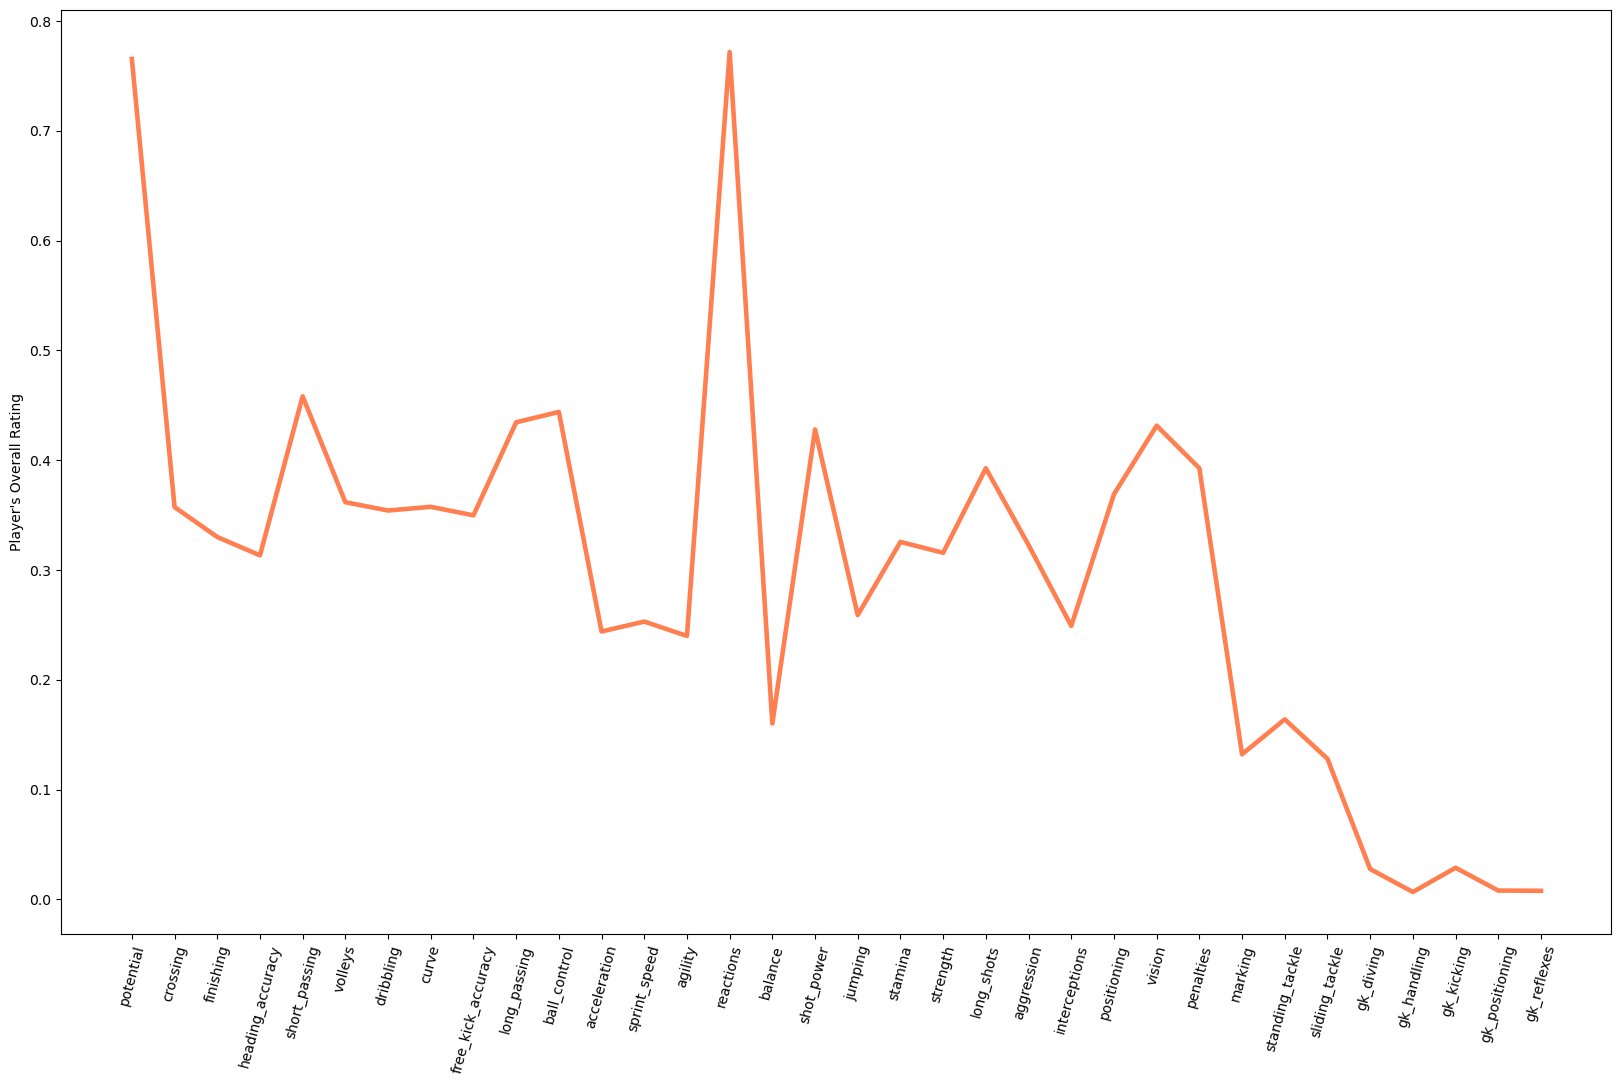

In [26]:
# let's plot above dataframe using the function we created
    
plot_dataframe(df2, 'Player\'s Overall Rating')

**Clustering Players into Similar Groups**



In [27]:
# Define the features you want to use for grouping players

select5features = ['gk_kicking', 'potential', 'marking', 'interceptions', 'standing_tackle']
select5features

['gk_kicking', 'potential', 'marking', 'interceptions', 'standing_tackle']

In [28]:
# Generate a new dataframe by selecting the features you just defined

df_select = df[select5features].copy(deep=True)

In [29]:
df_select.head()

,gk_kicking,potential,marking,interceptions,standing_tackle
26777,7.0,61.0,50.0,66.0,59.0
66605,13.0,67.0,40.0,23.0,49.0
2314,8.0,67.0,49.0,52.0,55.0
48909,16.0,65.0,37.0,42.0,50.0
147057,60.0,84.0,14.0,21.0,14.0


**Perform KMeans Clustering**

In [31]:
 #Perform scaling on the dataframe containing the features

data = scale(df_select)

# Define number of clusters
noOfClusters = 4

# Train a model
model = KMeans(init='k-means++', n_clusters=noOfClusters, n_init=20).fit(data)

In [32]:
print(90*'_')
print("\nCount of players in each cluster")
print(90*'_')

pd.value_counts(model.labels_, sort=False)

__________________________________________________________________________________________

Count of players in each cluster
__________________________________________________________________________________________


C:\Users\Michael Craig\AppData\Local\Temp\ipykernel_2688\2470493507.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(model.labels_, sort=False)


2    50205
3    55901
1    23777
0    50471
Name: count, dtype: int64

In [36]:

# Create DataFrame for cluster centers
P = pd.DataFrame(model.cluster_centers_, columns=select5features)
P['Cluster'] = np.arange(len(P))

# Display cluster centers
print(P)


   gk_kicking  potential   marking  interceptions  standing_tackle  Cluster
0   -0.040147   0.704649  1.027828       0.982643         1.030305        0
1    1.920634   0.037566 -1.111795      -0.653380        -1.201050        1
2   -0.337588  -0.843120  0.548344       0.407417         0.550814        2
3   -0.477122   0.105724 -0.947755      -0.975259        -0.914254        3


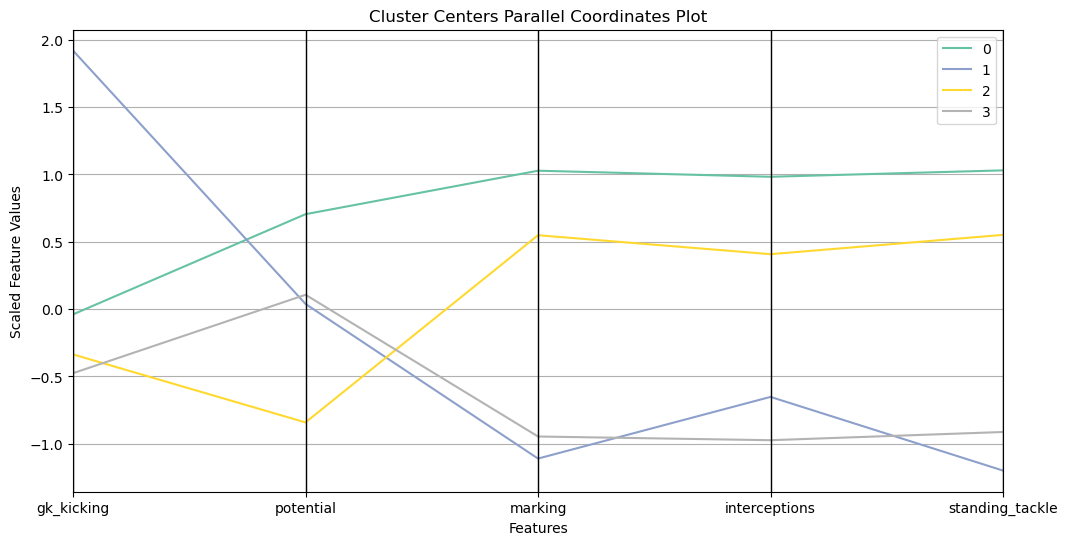

In [38]:


from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

# Ensure 'Cluster' is string type for coloring
P['Cluster'] = P['Cluster'].astype(str)

plt.figure(figsize=(12,6))
parallel_coordinates(P, class_column='Cluster', colormap=plt.get_cmap("Set2"))
plt.title('Cluster Centers Parallel Coordinates Plot')
plt.xlabel('Features')
plt.ylabel('Scaled Feature Values')
plt.show()
